## Algorithm — Modeling a planar source of neutrons (1D diffusion)

### Goal
Solve the 1D, mono-energetic neutron diffusion problem in a finite slab for $x \in [0,x_0]$
with a **planar source at $x=0$** emitting a strength $S$ (with the $4\pi$ emission convention),
and compare the **analytical** and **finite-difference numerical** solutions.

### Physical model
For $x>0$, we solve the steady-state diffusion equation:
$$
-\frac{d}{dx}\!\left(D\,\frac{d\phi}{dx}\right) + \Sigma_a\,\phi = 0,
\qquad
D=\frac{1}{3\Sigma_{tr}} \approx \frac{1}{3(\Sigma_a+\Sigma_s)}.
$$
Here, $\phi(x)$ is the scalar flux, $D$ the diffusion coefficient, $\Sigma_a$ the macroscopic
absorption cross section, and $\Sigma_s$ the macroscopic scattering cross section.

### Analytical solution
1. Define the attenuation parameter:
$$
k=\sqrt{\frac{\Sigma_a}{D}}.
$$

2. Solve the ODE in the slab using the boundary conditions:

- **Source boundary at $x=0$** (imposed current due to the planar source):
$$
-D\,\phi'(0)=J_0,
$$
where $J_0$ is chosen consistently with the source strength $S$ given in the statement.

- **Vacuum boundary at $x=x_0$**:
$$
\phi(x_0) + 2D\,\phi'(x_0)=0
\quad
\left(\text{equivalently } J(x_0)=\tfrac{1}{2}\phi(x_0)\right).
$$

3. Obtain $\phi_{\mathrm{ana}}(x)$ and report $\phi_{\mathrm{ana}}(0)$ and $\phi_{\mathrm{ana}}(x_0)$.

### Numerical solution (finite differences)
We discretize $x\in[0,x_0]$ with mesh size $\Delta x$ and nodes $x_i=i\Delta x$.
Unknowns are $\phi_i \approx \phi(x_i)$.

4. **Interior nodes** $i=1,\dots,N-1$:
apply central differences to get the tridiagonal relation
$$
a_W\,\phi_{i-1} + a_P\,\phi_i + a_E\,\phi_{i+1} = b_i,
$$
where $a_W,a_P,a_E$ follow from the discretization of
$-D\,d^2\phi/dx^2 + \Sigma_a\phi$.

5. **Boundary rows**:
- At $x=0$, enforce the source boundary condition by introducing (and eliminating)
a half-node (e.g. $\phi_{-1/2}$) to obtain an equation linking $\phi_0$ and $\phi_1$.
- At $x=x_0$, enforce the vacuum condition by eliminating the half-node
(e.g. $\phi_{N+1/2}$) to obtain the last row.

6. Assemble the linear system:
$$
A\,\Phi = B,
\qquad
\Phi = [\phi_0,\phi_1,\dots,\phi_N]^T,
$$
and solve it with a standard linear solver to obtain $\phi_{\mathrm{num}}(x_i)$.

### Verification and outputs
7. Compare analytical and numerical solutions:
- plot $\phi_{\mathrm{ana}}(x)$ and $\phi_{\mathrm{num}}(x_i)$;
- compute and plot the pointwise absolute difference for $\Delta x=0.1\ \mathrm{cm}$:
$$
e(x_i)=\left|\phi_{\mathrm{num}}(x_i)-\phi_{\mathrm{ana}}(x_i)\right|;
$$
- report $\phi_{\mathrm{num}}(0)$ and $\phi_{\mathrm{num}}(x_0)$ (4 decimal points).

8. Mesh refinement study:
repeat the numerical solve for several $\Delta x$ values and plot $e(x_0)$ versus $\Delta x$,
then comment on the observed convergence trend (order of accuracy and boundary-condition
discretization effects).

### Produced deliverables
- Printed values: $\phi(0)$ and $\phi(x_0)$ for analytical and numerical solutions.
- Plots: analytical vs numerical flux, absolute error distribution, and $e(x_0)$ vs $\Delta x$.


In [1]:
# Exercise 1: analytical solution of phi'' - phi/L^2 = 0 with
# left boundary: -D*phi'(0+) = S/2  (planar isotropic source)
# right boundary: vacuum (Marshak) -> phi(x0 + z0) = 0, with z0 = 2.131*D

import numpy as np

# ----- problem data -----
Sigma_a = 0.02
Sigma_s = 4.0
Sigma_t = Sigma_a + Sigma_s
D = 1.0 / (3.0 * Sigma_t)

S = 1000.0
x0 = 10.0
z0 = 2.131 * D

# diffusion length
L = np.sqrt(D / Sigma_a)
k = 1.0 / L

# analytical phi(x) (compact form that satisfies both BCs)
def phi_analytic(x):
    return (S / (2.0 * D * k)) * np.sinh(k * (x0 + z0 - x)) / np.cosh(k * (x0 + z0))

# values requested
phi_0   = phi_analytic(0.0)
phi_x0  = phi_analytic(x0)

print(f"D = {D:.6f} cm")
print(f"L = {L:.6f} cm,  z0 = {z0:.6f} cm")
print(f"phi(0)   = {phi_0:.6e}")
print(f"phi(x0)  = {phi_x0:.6e}")



D = 0.082919 cm
L = 2.036157 cm,  z0 = 0.176700 cm
phi(0)   = 1.227691e+04
phi(x0)  = 1.440482e+01


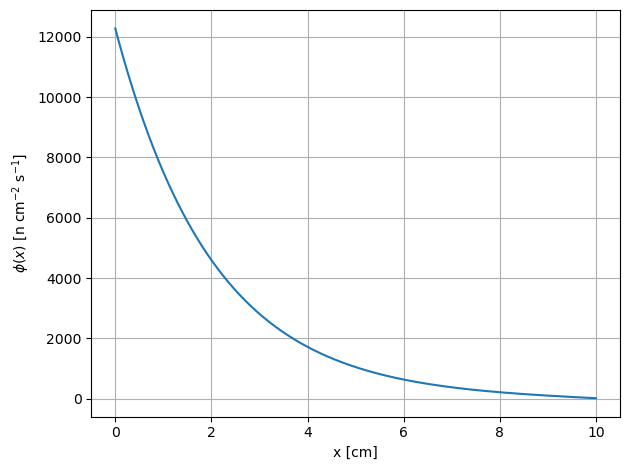

In [2]:
# -------------------------------
# Q1) Plot analytical solution
# -------------------------------

import os
import numpy as np
import matplotlib.pyplot as plt

x_plot = np.linspace(0.0, x0, 600)
phi_plot = phi_analytic(x_plot)

plt.figure()
plt.plot(x_plot, phi_plot)
plt.xlabel("x [cm]")
plt.ylabel(r"$\phi(x)$ [n cm$^{-2}$ s$^{-1}$]")
plt.grid(True)
plt.tight_layout()

plt.show()


In [3]:
# --- Discretized equations + coefficient forms + STRUCTURE matrix A  ---

import numpy as np

# 1) Discretized diffusion equations
print("=== DISCRETIZED DIFFUSION EQUATIONS ===\n")

# LHS (x= i = 1) with planar source -> net current C = S/2
print("LHS (i = 1, planar source -> net current C = S/2):")
print("  -(β_2/Δx^2) * θ_2  +  (β_2/Δx^2 + Σ_a,1) * θ_1  =  Q_1 + C/Δx\n")

# Interior (x= i = 2..N-1)
print("Interior (i = 2..N-1):")
print("  -(β_{i-1}/Δx^2) * θ_{i-1}  +  ( (β_{i-1}+β_{i+1})/Δx^2 + Σ_a,i ) * θ_i"
      "  -  (β_{i+1}/Δx^2) * θ_{i+1}  =  Q_i\n")

# RHS (x= i = N)
print("RHS (i = N):")
print("  -(β_{N-1}/Δx^2) * θ_{N-1}  +  ( β_{N-1}/Δx^2 + BC_N/Δx + Σ_a,N ) * θ_N  =  Q_N\n")

# 2) Coefficient forms 
print("=== COEFFICIENT FORMS ===\n")

print("LHS row (i = 1):")
print("  A[1,1] =  β_2/Δx^2 + Σ_a,1")
print("  A[1,2] = -β_2/Δx^2")
print("  b[1]   =  Q_1 + C/Δx\n")

print("Interior row (generic i = 2..N-1):")
print("  A[i,i-1] = -β_{i-1}/Δx^2")
print("  A[i,i]   =  (β_{i-1}+β_{i+1})/Δx^2 + Σ_a,i")
print("  A[i,i+1] = -β_{i+1}/Δx^2")
print("  b[i]     =  Q_i\n")

print("RHS row (i = N):")
print("  A[N,N-1] = -β_{N-1}/Δx^2")
print("  A[N,N]   =  β_{N-1}/Δx^2 + BC_N/Δx + Σ_a,N")
print("  b[N]     =  Q_N\n")

# 3) STRUCTURE-ONLY symbolic matrix A (placeholders A[i,j] / b[i])
def build_placeholder_A(N: int):
    """
    Create an N x N symbolic matrix with entries 'A[i,j]' and RHS vector 'b[i]'.
    Indices are 1-based in the printed labels to match the slides.
    """
    A = np.empty((N, N), dtype=object)
    b = np.empty(N, dtype=object)
    for i in range(1, N+1):
        for j in range(1, N+1):
            A[i-1, j-1] = f"A[{i},{j}]"
        b[i-1] = f"b[{i}]"
    return A, b

def pretty_print_boxed(A, b, name="A"):
    """
    Unicode boxed printer that aligns columns and shows 1..N indices.
    """
    N = A.shape[0]
    # Column widths based on max string length per column
    widths = []
    for j in range(N):
        maxlen = max(len(str(A[i, j])) for i in range(N))
        widths.append(max(maxlen, 6))  # ensure a minimum width

    def hline(left, mid, right, fill="─"):
        parts = [left]
        for j, w in enumerate(widths):
            parts.append(fill * (w + 2))
            parts.append(mid if j < N-1 else right)
        return "".join(parts)

    def fmt_cell(s, w):
        return " " + str(s).center(w) + " "

    # Header with column indices (1..N)
    header = ["    "] + [f"{j+1:^{widths[j]+2}}" for j in range(N)]
    print(f"=== {name} (N = {N}) ===")
    print(" ".join(header))
    print(hline("┌", "┬", "┐"))

    for i in range(N):
        row = [f"{i+1:>3} "]  # left index
        for j in range(N):
            row.append("│")
            row.append(fmt_cell(A[i, j], widths[j]))
        row.append("│")
        print("".join(row))
        print(hline("├", "┼", "┤") if i < N-1 else hline("└", "┴", "┘"))

    # RHS vector
    w_b = max(max(len(str(x)) for x in b), 6)
    print("\nRHS vector b:")
    print(f" index {'value'.center(w_b)}")
    print(" ───── " + "─" * w_b)
    for i in range(N):
        print(f" {i+1:>5} {str(b[i]).center(w_b)}")
    print()

# 6x6 matrix only for visualizing the patern
N_demo = 6

A_sym, b_sym = build_placeholder_A(N_demo)
pretty_print_boxed(A_sym, b_sym, name="Matrix A (structure only)")


=== DISCRETIZED DIFFUSION EQUATIONS ===

LHS (i = 1, planar source -> net current C = S/2):
  -(β_2/Δx^2) * θ_2  +  (β_2/Δx^2 + Σ_a,1) * θ_1  =  Q_1 + C/Δx

Interior (i = 2..N-1):
  -(β_{i-1}/Δx^2) * θ_{i-1}  +  ( (β_{i-1}+β_{i+1})/Δx^2 + Σ_a,i ) * θ_i  -  (β_{i+1}/Δx^2) * θ_{i+1}  =  Q_i

RHS (i = N):
  -(β_{N-1}/Δx^2) * θ_{N-1}  +  ( β_{N-1}/Δx^2 + BC_N/Δx + Σ_a,N ) * θ_N  =  Q_N

=== COEFFICIENT FORMS ===

LHS row (i = 1):
  A[1,1] =  β_2/Δx^2 + Σ_a,1
  A[1,2] = -β_2/Δx^2
  b[1]   =  Q_1 + C/Δx

Interior row (generic i = 2..N-1):
  A[i,i-1] = -β_{i-1}/Δx^2
  A[i,i]   =  (β_{i-1}+β_{i+1})/Δx^2 + Σ_a,i
  A[i,i+1] = -β_{i+1}/Δx^2
  b[i]     =  Q_i

RHS row (i = N):
  A[N,N-1] = -β_{N-1}/Δx^2
  A[N,N]   =  β_{N-1}/Δx^2 + BC_N/Δx + Σ_a,N
  b[N]     =  Q_N

=== Matrix A (structure only) (N = 6) ===
        1        2        3        4        5        6    
┌────────┬────────┬────────┬────────┬────────┬────────┐
  1 │ A[1,1] │ A[1,2] │ A[1,3] │ A[1,4] │ A[1,5] │ A[1,6] │
├────────┼────────

In [4]:
# Exercice 2--- Interior finite-difference relation (no BCs) and A-coefficients (4 decimals) ---

# Physical data
Sigma_a = 0.02   # cm^-1
Sigma_s = 4.0    # cm^-1
Sigma_t = Sigma_a + Sigma_s
D = 1.0 / (3.0 * Sigma_t)   # difussion coeficient[cm]

# Mesh
dx = 0.1                    # cm
inv_dx2 = 1.0 / (dx*dx)     # 1/(dx)^2

# General interior relation:
general_relation = (
    "(- beta_{i-1}/dx^2) * theta_{i-1} "
    "+ [ (beta_{i-1}+beta_{i+1})/dx^2 + Sigma_a ] * theta_i "
    "+ (- beta_{i+1}/dx^2) * theta_{i+1} = Q_i"
)

print("Interior relation (general, no BCs):")
print(general_relation)

# Matrix A  interior rows coeficients
A_im1 = - D * inv_dx2
A_i   = (D + D) * inv_dx2 + Sigma_a
A_ip1 = - D * inv_dx2

print("\nAssociated matrix A-coefficients at any interior node:")
print(f"A[i,i-1] = {A_im1:.4f}")
print(f"A[i,i]   = {A_i:.4f}")
print(f"A[i,i+1] = {A_ip1:.4f}")

# Used Values
print("\nValues used:")
print(f"Sigma_a = {Sigma_a:.5f} cm^-1,  Sigma_s = {Sigma_s:.5f} cm^-1")
print(f"D = {D:.6f} cm,  dx = {dx:.3f} cm")


Interior relation (general, no BCs):
(- beta_{i-1}/dx^2) * theta_{i-1} + [ (beta_{i-1}+beta_{i+1})/dx^2 + Sigma_a ] * theta_i + (- beta_{i+1}/dx^2) * theta_{i+1} = Q_i

Associated matrix A-coefficients at any interior node:
A[i,i-1] = -8.2919
A[i,i]   = 16.6037
A[i,i+1] = -8.2919

Values used:
Sigma_a = 0.02000 cm^-1,  Sigma_s = 4.00000 cm^-1
D = 0.082919 cm,  dx = 0.100 cm


In [5]:
# --- Boundary conditions, face–center relations, and A-row coefficients (4 decimals) ---

import numpy as np

# Physical data
Sigma_a = 0.02        # Absortion cross-section, cm^-1
Sigma_s = 4.0         # Scattering cross-section, cm^-1
Sigma_t = Sigma_a + Sigma_s  # Total cross-section
D = 1.0 / (3.0 * Sigma_t)    # Diffusion coefficient [cm]

# Source and mesh
S  = 1000.0
C  = S / 2.0                 # Net current at LHS (1/2 factor due to planar isotropic source)
dx = 0.1                     # Mesh size, cm
inv_dx2 = 1.0 / (dx * dx)    # 1/(dx)^2

# --- 1) Boundary conditions used: ---
print("BOUNDARY CONDITIONS:")
print(" LHS (x=0):  J(0+) = -D * θ'(0+) = S/2   ->   θ'(0+) = -S/(2D)") #From Fick's law --> J(0+)
print(" RHS (x=x0): zero incoming partial current from the right:")
print("             J^-(N+1/2) = θ_(N+1/2)/4 + D * (θ_(N+1/2) - θ_N) / dx = 0")

# --- 2) Face–center relations derived from the BCs ---

# LHS: face (1-1/2) in terms of center (1):
lhs_factor = dx / (2.0 * D)  # dx/2D
print("\nFACE–CENTER RELATION (LHS):")
print(" From the net-current BC at x=0 -> face 1-1/2:")
print("  θ_(1-1/2) = θ_1 + (dx/(2D)) * C")
print(f"  => θ_(1-1/2) = θ_1 + ({dx}/(2*{D:.6f})) * C = θ_1 + {lhs_factor:.6f} * C")

# RHS: face (N+1/2) in terms of center (N):
rhs_ratio = (D/dx) / (0.25 + D/dx)  # (D/dx) / (1/4 + D/dx)
print("\nFACE–CENTER RELATION (RHS):")
print(" From  J^-(N+1/2) = θ_(N+1/2)/4 + D*(θ_(N+1/2) - θ_N)/dx = 0  we obtain:")
print("  θ_(N+1/2) = [(D/dx) / (1/4 + D/dx)] * θ_N")
print(f"  => θ_(N+1/2) = (({D:.6f}/{dx}) / (1/4 + {D:.6f}/{dx})) * θ_N = {rhs_ratio:.6f} * θ_N")

# --- 3) Matrix A coefficients at LHS and RHS (with 4 decimals) ---
beta = D

# LHS (x=i=1), row coefficients:
A11 =  beta * inv_dx2 + Sigma_a
A12 = -beta * inv_dx2
b1  =  C / dx

print("\nMATRIX A LHS row coefficients (i=1):")
print(f"A[1,1] = {A11:.4f}")
print(f"A[1,2] = {A12:.4f}")
print(f"b[1]   = {b1:.4f}")

# RHS (x=i=N), row coefficients:
BCN = 1.0 / (2.0*(dx/(4.0*D) + 1.0))
ANNm1 = -beta * inv_dx2
ANN   =  beta * inv_dx2 + BCN/dx + Sigma_a
bN    =  0.0  # QN = 0

print("\nMATRIX A RHS row coefficients (i=N, vacuum):")
print(f"A[N,N-1] = {ANNm1:.4f}")
print(f"A[N,N]   = {ANN:.4f}")
print(f"b[N]     = {bN:.4f}")

# Numerical values used
print("\nVALUES USED:")
print(f"Sigma_a = {Sigma_a:.5f} cm^-1,  Sigma_s = {Sigma_s:.5f} cm^-1,  D = {D:.6f} cm,  dx = {dx:.3f} cm")


BOUNDARY CONDITIONS:
 LHS (x=0):  J(0+) = -D * θ'(0+) = S/2   ->   θ'(0+) = -S/(2D)
 RHS (x=x0): zero incoming partial current from the right:
             J^-(N+1/2) = θ_(N+1/2)/4 + D * (θ_(N+1/2) - θ_N) / dx = 0

FACE–CENTER RELATION (LHS):
 From the net-current BC at x=0 -> face 1-1/2:
  θ_(1-1/2) = θ_1 + (dx/(2D)) * C
  => θ_(1-1/2) = θ_1 + (0.1/(2*0.082919)) * C = θ_1 + 0.603000 * C

FACE–CENTER RELATION (RHS):
 From  J^-(N+1/2) = θ_(N+1/2)/4 + D*(θ_(N+1/2) - θ_N)/dx = 0  we obtain:
  θ_(N+1/2) = [(D/dx) / (1/4 + D/dx)] * θ_N
  => θ_(N+1/2) = ((0.082919/0.1) / (1/4 + 0.082919/0.1)) * θ_N = 0.768344 * θ_N

MATRIX A LHS row coefficients (i=1):
A[1,1] = 8.3119
A[1,2] = -8.2919
b[1]   = 5000.0000

MATRIX A RHS row coefficients (i=N, vacuum):
A[N,N-1] = -8.2919
A[N,N]   = 12.1536
b[N]     = 0.0000

VALUES USED:
Sigma_a = 0.02000 cm^-1,  Sigma_s = 4.00000 cm^-1,  D = 0.082919 cm,  dx = 0.100 cm


In [6]:
import numpy as np

# ---------- Problem data (homogeneous slab) ----------
Sigma_a = 0.02
Sigma_s = 4.0
Sigma_t = Sigma_a + Sigma_s
D = 1.0 / (3.0 * Sigma_t)

dx  = 0.1          # cm
x0  = 10.0         # cm
N   = int(round(x0/dx))
S   = 1000.0
C   = S/2.0

inv_dx2 = 1.0/(dx*dx)
beta = D

# ---------- Assemble tridiagonal A and RHS b (stored as three diagonals) ----------
a = np.zeros(N)   # sub-diagonal
d = np.zeros(N)   # main diagonal
c = np.zeros(N)   # super-diagonal
b = np.zeros(N)

# LHS row (i=1)
d[0] =  beta*inv_dx2 + Sigma_a
c[0] = -beta*inv_dx2
b[0] =  C/dx

# Interior rows (i=2..N-1)
for i in range(1, N-1):
    a[i] = -beta*inv_dx2
    d[i] = (beta + beta)*inv_dx2 + Sigma_a
    c[i] = -beta*inv_dx2
    b[i] =  0.0

# RHS row (i=N) – vacuum (Marshak)
BCN = 1.0 / (2.0*(dx/(4.0*D) + 1.0))
a[N-1] = -beta*inv_dx2
d[N-1] =  beta*inv_dx2 + BCN/dx + Sigma_a
b[N-1] =  0.0

# ---------- SOR iterative solver (returns full theta) ----------
def sor_tridiag(a, d, c, b, omega=1.7, x0=None, tol=1e-12, max_iter=20000):
    n = len(d)
    x = np.zeros(n) if x0 is None else x0.copy()
    res_hist = []

    def residual_inf(x):
        r0 = b[0]   - d[0]*x[0]   - c[0]*x[1]
        rn = b[-1]  - a[-1]*x[-2] - d[-1]*x[-1]
        if n == 2:
            r_mid_max = 0.0
        else:
            r_mid = b[1:-1] - (a[1:-1]*x[:-2] + d[1:-1]*x[1:-1] + c[1:-1]*x[2:])
            r_mid_max = np.max(np.abs(r_mid))
        return max(abs(r0), abs(rn), r_mid_max)

    for k in range(max_iter):
        # first row
        x_new = (b[0] - c[0]*x[1]) / d[0]
        x[0] = (1-omega)*x[0] + omega*x_new
        # interior
        for i in range(1, n-1):
            x_new = (b[i] - a[i]*x[i-1] - c[i]*x[i+1]) / d[i]
            x[i] = (1-omega)*x[i] + omega*x_new
        # last row
        x_new = (b[-1] - a[-1]*x[-2]) / d[-1]
        x[-1] = (1-omega)*x[-1] + omega*x_new

        res = residual_inf(x)
        res_hist.append(res)
        if res < tol:
            return x, k+1, res_hist

    return x, max_iter, res_hist

# Choose relaxation and solve
omega = 1.7
theta, iters, res_hist = sor_tridiag(a, d, c, b, omega=omega, tol=1e-12)

# ---------- Report + FULL vector ----------
print("=== SOR solve of A θ = b ===")
print(f"N={N}, dx={dx} cm, D={D:.6f} cm, BCN={BCN:.6f}, ω={omega}")
print(f"Converged in {iters} iterations; final residual ||b-Aθ||_∞ = {res_hist[-1]:.3e}\n")

# Print the whole theta (indexing 1..N to match slides)
for i, val in enumerate(theta, start=1):
    print(f"θ[{i:3d}] = {val:.8e}")



=== SOR solve of A θ = b ===
N=100, dx=0.1 cm, D=0.082919 cm, BCN=0.384172, ω=1.7
Converged in 20000 iterations; final residual ||b-Aθ||_∞ = 2.910e-11

θ[  1] = 1.19790980e+04
θ[  2] = 1.14049916e+04
θ[  3] = 1.08583940e+04
θ[  4] = 1.03379869e+04
θ[  5] = 9.84251501e+03
θ[  6] = 9.37078325e+03
θ[  7] = 8.92165383e+03
θ[  8] = 8.49404342e+03
θ[  9] = 8.08692066e+03
θ[ 10] = 7.69930354e+03
θ[ 11] = 7.33025715e+03
θ[ 12] = 6.97889133e+03
θ[ 13] = 6.64435860e+03
θ[ 14] = 6.32585207e+03
θ[ 15] = 6.02260349e+03
θ[ 16] = 5.73388143e+03
θ[ 17] = 5.45898949e+03
θ[ 18] = 5.19726463e+03
θ[ 19] = 4.94807558e+03
θ[ 20] = 4.71082128e+03
θ[ 21] = 4.48492949e+03
θ[ 22] = 4.26985534e+03
θ[ 23] = 4.06508009e+03
θ[ 24] = 3.87010981e+03
θ[ 25] = 3.68447423e+03
θ[ 26] = 3.50772561e+03
θ[ 27] = 3.33943762e+03
θ[ 28] = 3.17920435e+03
θ[ 29] = 3.02663933e+03
θ[ 30] = 2.88137455e+03
θ[ 31] = 2.74305966e+03
θ[ 32] = 2.61136102e+03
θ[ 33] = 2.48596099e+03
θ[ 34] = 2.36655709e+03
θ[ 35] = 2.25286133e+03
θ[ 36] =

=== Numerical boundary fluxes reconstructed from `theta` ===
phi_num(0)  = 1.2281e+04  [n cm^-2 s^-1]
phi_num(x0) = 1.3624e+01  [n cm^-2 s^-1]

=== Analytical boundary fluxes ===
phi_ana(0)  = 1.2277e+04  [n cm^-2 s^-1]
phi_ana(x0) = 1.4405e+01  [n cm^-2 s^-1]

=== Absolute errors at boundaries ===
|phi_num(0)-phi_ana(0)|   = 3.6882e+00  [n cm^-2 s^-1]
|phi_num(x0)-phi_ana(x0)| = 7.8044e-01  [n cm^-2 s^-1]


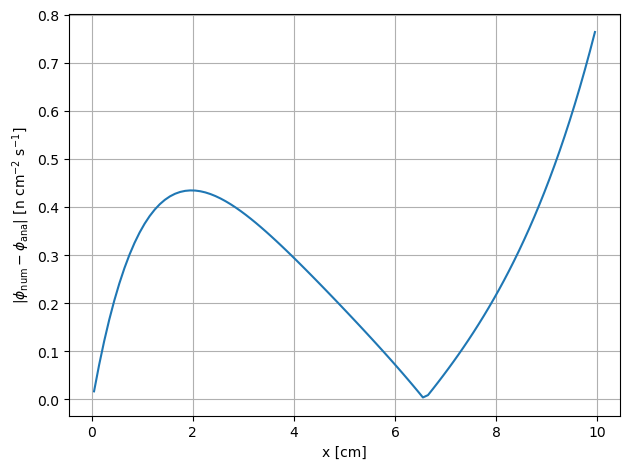

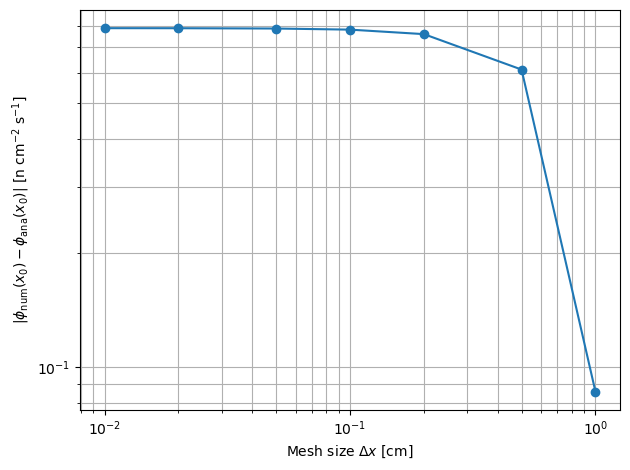

In [7]:
# -----------------------------------------
# Q5) Post-processing: numerical boundary fluxes + required plots
# (place this cell right AFTER the SOR-solver cell that defines `theta`)
# -----------------------------------------

import os
import numpy as np
import matplotlib.pyplot as plt


# ---- 1) Numerical flux values at boundaries from face-center relations ----
# Left boundary (x=0): theta_(1/2) = theta_1 + (dx/(2D))*C
phi_num_0 = theta[0] + (dx/(2.0*D))*C

# Right boundary (x=x0), Marshak vacuum: theta_(N+1/2) = alpha * theta_N
alpha = (D/dx) / (0.25 + D/dx)
phi_num_x0 = alpha * theta[-1]

print("=== Numerical boundary fluxes reconstructed from `theta` ===")
print(f"phi_num(0)  = {phi_num_0:.4e}  [n cm^-2 s^-1]")
print(f"phi_num(x0) = {phi_num_x0:.4e}  [n cm^-2 s^-1]\n")

#(Compare to analytical values (requires that the analytical cell was run)
phi_ana_0  = phi_analytic(0.0)
phi_ana_x0 = phi_analytic(x0)
print("=== Analytical boundary fluxes ===")
print(f"phi_ana(0)  = {phi_ana_0:.4e}  [n cm^-2 s^-1]")
print(f"phi_ana(x0) = {phi_ana_x0:.4e}  [n cm^-2 s^-1]\n")

print("=== Absolute errors at boundaries ===")
print(f"|phi_num(0)-phi_ana(0)|   = {abs(phi_num_0 - phi_ana_0):.4e}  [n cm^-2 s^-1]")
print(f"|phi_num(x0)-phi_ana(x0)| = {abs(phi_num_x0 - phi_ana_x0):.4e}  [n cm^-2 s^-1]")

# ---- 2) Plot distance between solutions at each mesh point (dx = current dx = 0.1 cm) ----
# theta is at cell centers: x_i = (i-0.5)*dx
x_centers = (np.arange(N) + 0.5)*dx
phi_ana_centers = phi_analytic(x_centers)
distance = np.abs(theta - phi_ana_centers)

plt.figure()
plt.plot(x_centers, distance)
plt.xlabel("x [cm]")
plt.ylabel(r"$|\phi_{\mathrm{num}}-\phi_{\mathrm{ana}}|$ [n cm$^{-2}$ s$^{-1}$]")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- 3) Error at phi(x0) vs mesh size (vary dx), using a fast tridiagonal (Thomas) solver ----
def thomas_tridiag(a, d, c, b):
    """Solve tridiagonal system with vectors a (sub), d (diag), c (super)."""
    n = len(d)
    cp = np.zeros(n)
    dp = np.zeros(n)
    cp[0] = c[0] / d[0]
    dp[0] = b[0] / d[0]
    for i in range(1, n):
        denom = d[i] - a[i] * cp[i-1]
        cp[i] = (c[i] / denom) if i < n-1 else 0.0
        dp[i] = (b[i] - a[i] * dp[i-1]) / denom
    x = np.zeros(n)
    x[-1] = dp[-1]
    for i in range(n-2, -1, -1):
        x[i] = dp[i] - cp[i] * x[i+1]
    return x

def solve_fd_for_dx(dx_test, Sigma_a=0.02, Sigma_s=4.0, S=1000.0, x0=10.0):
    """Build A*theta=b for given dx and solve with Thomas; return theta and boundary phi(x0)."""
    Sigma_t = Sigma_a + Sigma_s
    Dloc = 1.0/(3.0*Sigma_t)
    Cloc = S/2.0
    Nloc = int(round(x0/dx_test))
    inv_dx2 = 1.0/(dx_test*dx_test)
    beta = Dloc

    a = np.zeros(Nloc)
    d = np.zeros(Nloc)
    c = np.zeros(Nloc)
    b = np.zeros(Nloc)

    # i=1
    d[0] = beta*inv_dx2 + Sigma_a
    c[0] = -beta*inv_dx2
    b[0] = Cloc/dx_test

    # interior
    for i in range(1, Nloc-1):
        a[i] = -beta*inv_dx2
        d[i] = 2.0*beta*inv_dx2 + Sigma_a
        c[i] = -beta*inv_dx2
        b[i] = 0.0

    # i=N, Marshak vacuum
    BCN = 1.0 / (2.0*(dx_test/(4.0*Dloc) + 1.0))
    a[Nloc-1] = -beta*inv_dx2
    d[Nloc-1] = beta*inv_dx2 + BCN/dx_test + Sigma_a
    b[Nloc-1] = 0.0

    theta_loc = thomas_tridiag(a, d, c, b)

    # boundary flux at x0
    alpha_loc = (Dloc/dx_test) / (0.25 + Dloc/dx_test)
    phi_num_x0_loc = alpha_loc * theta_loc[-1]
    return theta_loc, phi_num_x0_loc

dx_list = np.array([1.0, 0.5, 0.2, 0.1, 0.05, 0.02, 0.01])
err_x0 = []

for dx_test in dx_list:
    _, phi_num_x0_test = solve_fd_for_dx(dx_test, Sigma_a=Sigma_a, Sigma_s=Sigma_s, S=S, x0=x0)
    err_x0.append(abs(phi_num_x0_test - phi_ana_x0))

err_x0 = np.array(err_x0)

plt.figure()
plt.loglog(dx_list, err_x0, marker="o")
plt.xlabel(r"Mesh size $\Delta x$ [cm]")
plt.ylabel(r"$|\phi_{\mathrm{num}}(x_0)-\phi_{\mathrm{ana}}(x_0)|$ [n cm$^{-2}$ s$^{-1}$]")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

